---
title: Pie Charts
subtitle: DS 2023 | Communicating with Data
type: lesson
publish: true
---

## Overview

Pie charts are good for things like budgets, diets, etc., where there is a metaphorical pie that is divided into component parts.

## A simple example

Let's create some imaginary data about someone's nutrient consumption in the course of a day.

The numeric values are in grams.

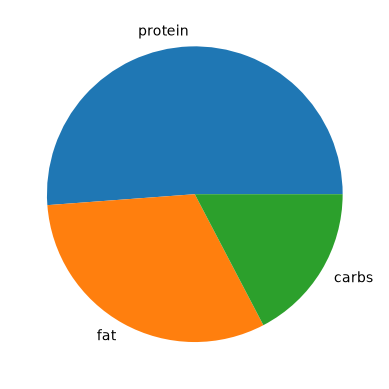

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

my_data = {
    'protein': 65,
    'fat': 40,
    'carbs': 22
}
df = pd.Series(my_data)
df.plot.pie()
plt.show()

## A more complex example

Let's now look at a classic data set -- the Titanic data set.

This data set shows the survival rate of passengers on the ill-fated vessel that sank in 1912.

It consists entirely of nominal data for $1316$ passengers.

These data are ideal for pie charts because: 

1. Many features contains exhaustive and exclusive labels, meaning every passenger must belong to one and only category from each feature, e.g. class and sex.
2. The number of values per feature is small.

We can use pie charts to display each feature's composition.

In [ ]:
import seaborn as sns

titanic = sns.load_dataset('titanic')
titanic

In [ ]:
titanic['age_group'] = np.where(titanic['age'] >= 18, 'adult', 'child')

We are only interest in a subset of categorial columns, so we select those.

In [ ]:
my_cols = ['sex', 'age_group', 'class','survived']

In [ ]:
titanic = titanic[my_cols]

In [ ]:
titanic

Now let's create a pie chart for each feature.

In [ ]:
dfs = {}
for col in my_cols:
    dfs[col] = titanic.value_counts(col)
# titanic_vcs = pd.concat(dfs.values(), keys=dfs.keys(), axis=0)

In [ ]:
for col in dfs:
    df = dfs[col]
    df.plot.pie(title=col.title(), figsize=(2,2))
    plt.show()

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(6,6))
for i, col in enumerate(titanic.columns):
    c = i % 2
    r = i // 2
    df = titanic.value_counts(col)
    df.plot.pie(title=col.title(), ax=ax[r,c])
plt.show()

## Joint probabilities

We can see that there are two kinds of features in the Titanic data set: those that define the _category_ of each person and one that defines the _fate_ each person. 

The first set may be thought of as input values and the second as the ouptput.

Let's group the data by the category features and get the value counts of the survival feature. The produces a data frame where the categorical features form the index and the survival feature is projected onto the column axis.

In [ ]:
titanic_vc = titanic[my_cols].value_counts().unstack(fill_value=0)
titanic_vc.columns = ['no','yes']
titanic_vc

In this form, the table tells us, "If a passenger was a first class adult male, what was their chance of surviving?"

We can use the survival rate data to compute a rough probability estimate as follows.

In [ ]:
titanic_vc['total'] = titanic_vc['yes'] + titanic_vc['no']
titanic_vc['s_rate'] = round(titanic_vc['yes'] / titanic_vc['total'], 2)
titanic_vc.sort_values('s_rate')

Since these data are exhaustive, exclusive, and relatively few, we can use a pie chart to visualize the probabilities.

:::{note}

Althought the categories are exhaustive and exclusive, the probabilities represented by the pie do not sum to $1$. This is because each value is a joint probability for each combination of categorical features.

:::

In [ ]:
titanic_vc.s_rate.sort_values().plot.pie(title="Survual Rates")
plt.show()

How readable is this chart? Does it easily show which category combinations had the highest and lowest survival rates? 

It turns out that pie charts become less useful as the number of categories increases.

In such cases, it is often better to fall back onto a bar chart.

The one below clearly shows which categories had the highest and lowest survival rates.

In [ ]:
ax = titanic_vc.s_rate.sort_values().plot.barh()
plt.show()

:::{note}

Be careful not to read too much into the survival rates of the first and second class children. Their total numbers are much smaller than the other categories.

Below, we visualize the fate of the adult passengers.

:::

In [ ]:
ax = (
    titanic_vc.query("age_group == 'adult'")
    .s_rate
    .sort_values()
    .plot.pie(title="Survival Rates of Adults")
)
plt.show()

## Arguments

- autopct
- explode
- starting

Using String FormattingYou can pass a standard Python formatting string to autopct to control decimal places.

- `autopct='%1.1f%%'`: Displays one decimal place (e.g., $12.5\%$).
- `autopct='%1.2f%%'`: Displays two decimal places (e.g., $12.50\%$).
- `autopct='%1.0f%%'`: Rounds to the nearest whole integer (e.g., $13\%$)

In [ ]:
key_col = 'survived'
dfs[key_col].plot.pie(autopct='%1.2f%%', title=key_col.title())
plt.show()

In [ ]:
explode_tuple = (0, 0.1, 0) 
dfs['class'].plot.pie(autopct='%1.2f%%', explode=explode_tuple)

In [ ]:
explode_tuple = (0, 0.1, 0) 
dfs['class'].plot.pie(autopct='%1.2f%%', explode=explode_tuple, startangle=90)

In [ ]:
explode_tuple = [0.025 for i in range(len(dfs['class']))]
dfs['class'].plot.pie(autopct='%1.2f%%', explode=explode_tuple, startangle=90)